# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [1]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [2]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


También está disponible: imagen_preprocesada.png
Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


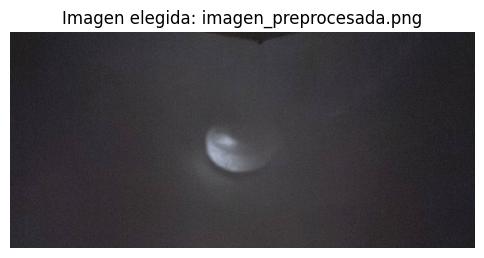

Color objetivo: blanco brillante (zona central de la lámpara)


In [3]:
# Elegí la imagen con la que vas a trabajar.
if Path("imagen_preprocesada.png").exists():
    nombre_imagen = "imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb = cargar_rgb(nombre_imagen)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "blanco brillante (zona central de la lámpara)"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


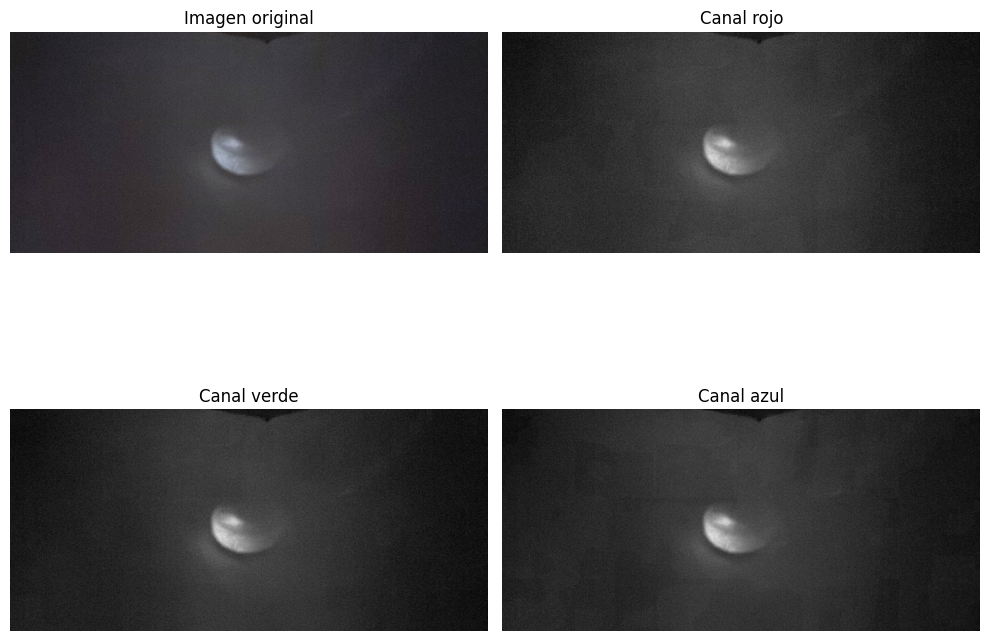

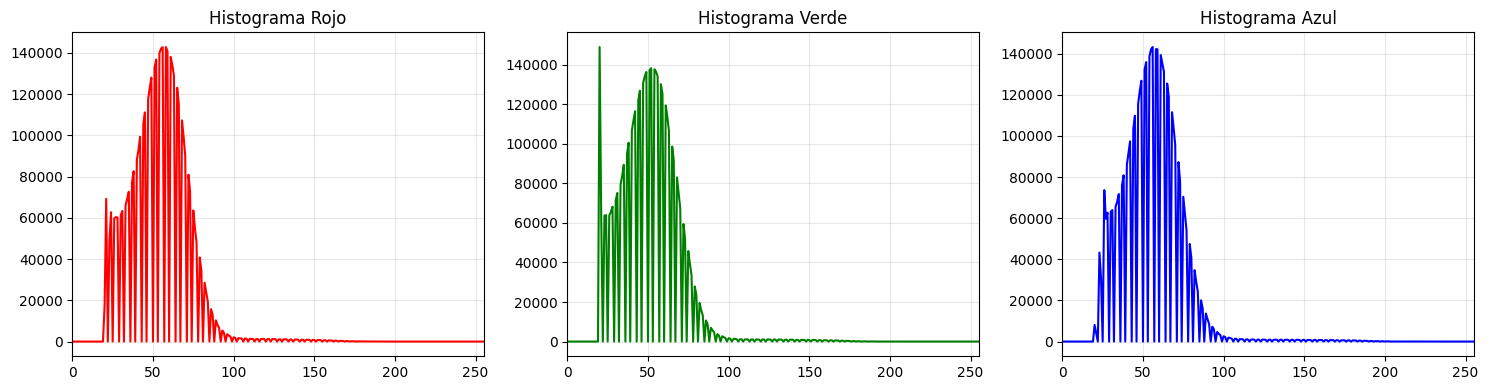

El canal más útil es cualquiera de los tres (o los tres juntos), porque al ser blanco el objeto, no hay un canal que lo destaque sobre los demás. Lo que sí es claro en los histogramas es que los píxeles de la lámpara están en la cola derecha (valores > 100-150), mientras que el fondo gris oscuro ocupa el pico central (~50).


In [9]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = "El canal más útil es cualquiera de los tres (o los tres juntos), porque al ser blanco el objeto, no hay un canal que lo destaque sobre los demás. " \
"Lo que sí es claro en los histogramas es que los píxeles de la lámpara están en la cola derecha (valores > 100-150), mientras que el fondo gris oscuro ocupa el pico central (~50)."
print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


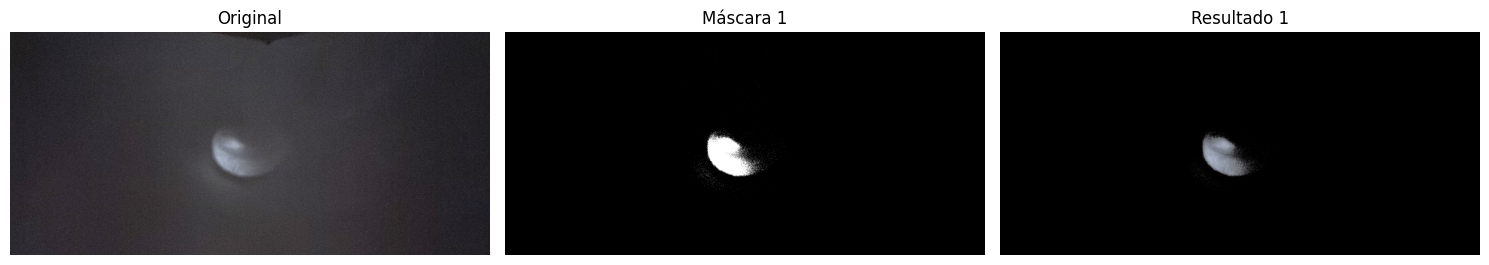

In [23]:
r_min, r_max = 100, 250
g_min, g_max = 100, 250
b_min, b_max = 100, 250

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


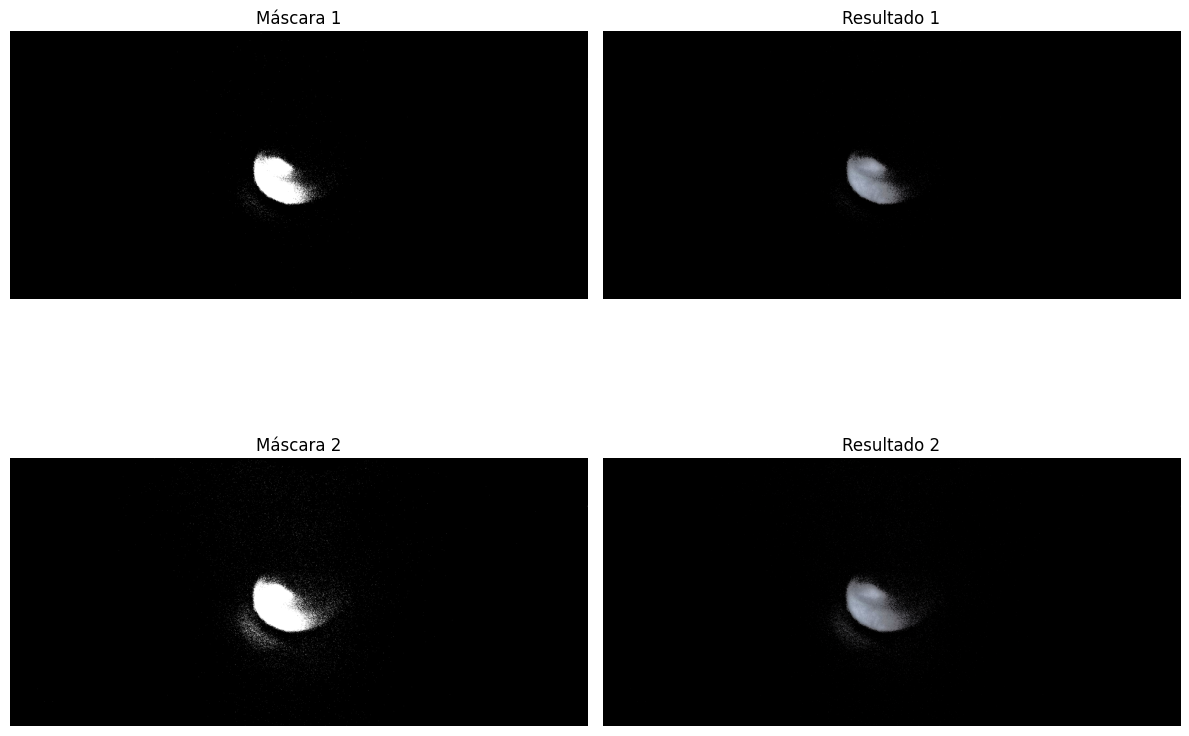

In [24]:
r_min_2, r_max_2 = 90, 255
g_min_2, g_max_2 = 90, 255
b_min_2, b_max_2 = 90, 255

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
2. ¿Qué canales te dieron la pista más útil?
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
4. ¿Qué limitaciones encontraste en este método?
5. Si tuvieras más tiempo, ¿qué mejorarías?

Respuestas:

1. El blanco brillante de una lámpara de techo fotografiada con una cámara oscura.

2. Los tres canales por igual (R, G y B), porque la lámpara emite luz blanca
   y sus histogramas eran casi idénticos. No hubo un canal dominante,
   la pista fue que los píxeles de la lámpara aparecían en la cola derecha
   de los tres histogramas (valores > 100), mientras el fondo gris
   se concentraba alrededor de 50.

3. Bajé los mínimos de 130 a 90 en los tres canales para capturar
   no solo el núcleo brillante sino también el halo difuso que rodea
   la lámpara, logrando una segmentación más completa del objeto.

4. El método RGB puro es sensible al brillo general de la imagen.
   Como el fondo también tiene tonos grises medios, bajar demasiado
   el umbral empieza a incluir píxeles del fondo. Además, la transición
   entre la lámpara y el fondo es gradual (por el halo difuso), lo que
   hace difícil definir un corte limpio con rangos fijos.

5. Probaría segmentar en espacio HSV en lugar de RGB, usando saturación
   baja + valor alto para detectar el blanco de forma más robusta.
   También aplicaría operaciones morfológicas (erosión/dilatación)
   para limpiar el ruido y rellenar huecos dentro de la máscara.


### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
